In [3]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv(r"C:\Users\akash kashyap\Data Analysis\Final Project for resume\EDA\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print(df.shape) # find total rows and columns or dataset structure
print(df.dtypes) # print each column data types
print(df.isnull().sum()) # print total null values form  each column

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [13]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [12]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [15]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)
print(df['TotalCharges'].isnull().sum())

(7032, 21)
0


In [19]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

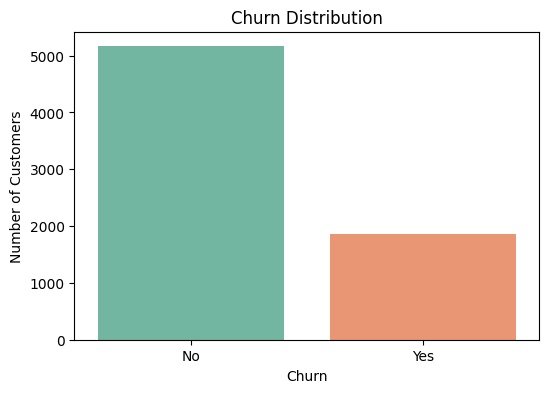

In [21]:
# Customer Churn Distribution graph
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', legend=False, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

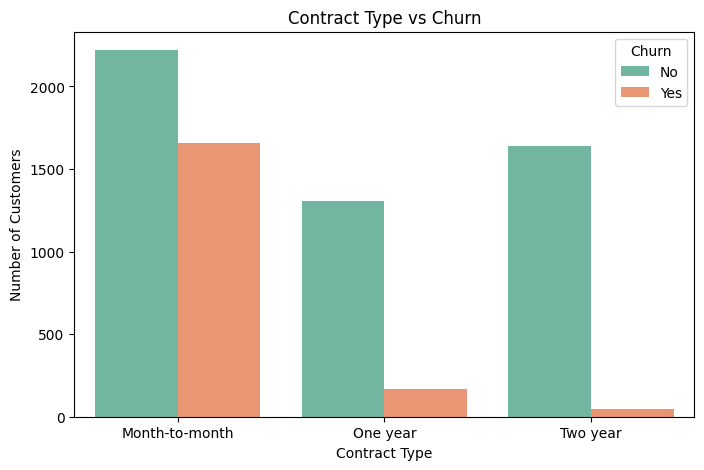

In [22]:
# Contract type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', data=df, hue='Churn', palette='Set2')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

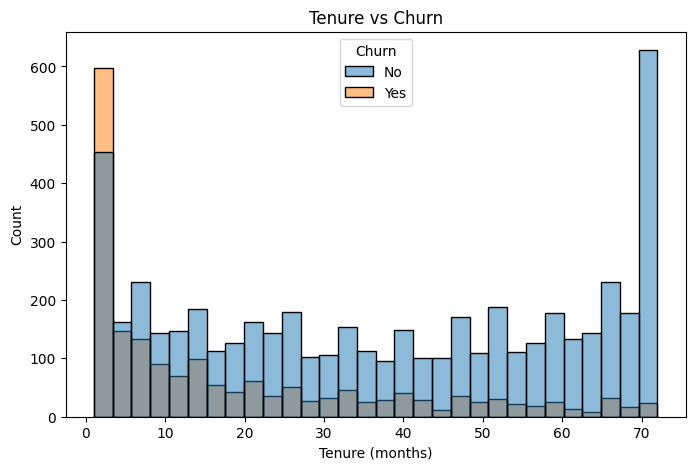

In [23]:
# Tenure vs Churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

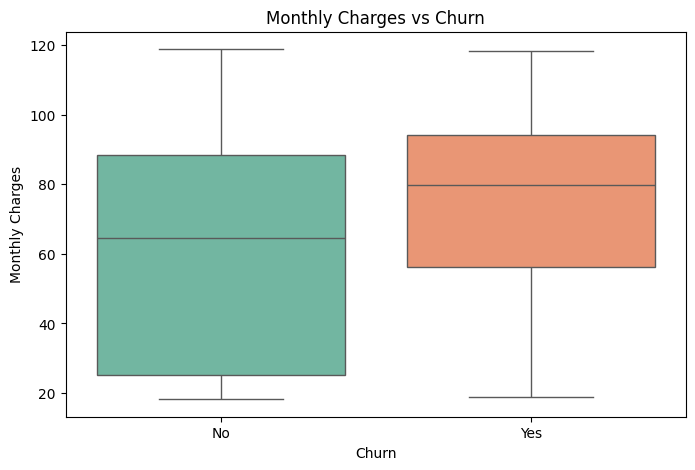

In [25]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', legend=False, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

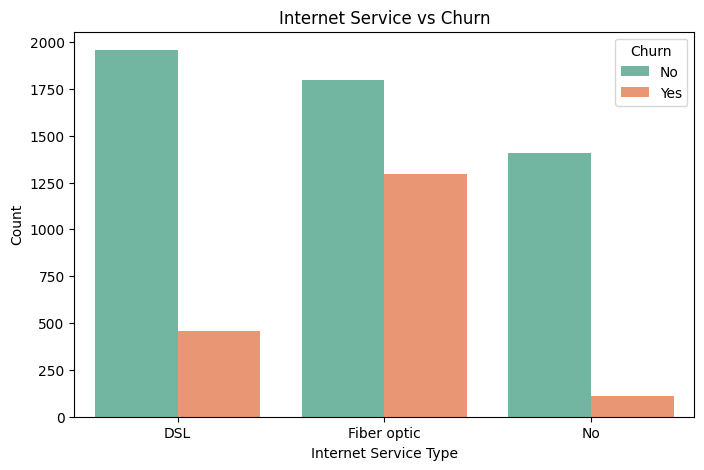

In [26]:
# Internet Service Vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', data=df, hue='Churn', palette='Set2')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Count')
plt.show()

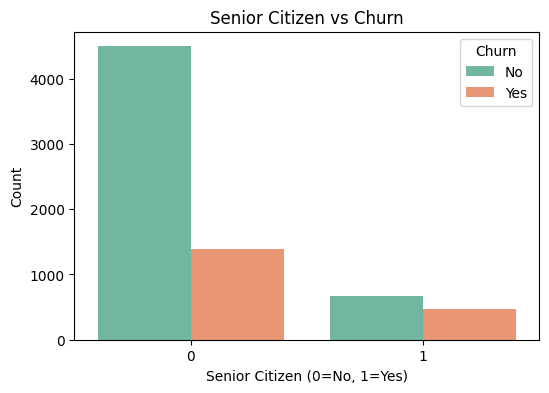

In [27]:
# Senior Citizen Vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', data=df, hue='Churn', palette='Set2')
plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

In [28]:
# Total revenue loss from churned customers
churned = df[df['Churn'] == 'Yes']
revenue_loss = churned['MonthlyCharges'].sum()
print(f"Monthly Revenue Loss: ${revenue_loss:,.2f}")


Monthly Revenue Loss: $139,130.85


In [29]:
print(f"Yearly Revenue Loss: ${revenue_loss * 12:,.2f}")

Yearly Revenue Loss: $1,669,570.20


In [30]:
# ============================================================
# CUSTOMER CHURN ANALYSIS — KEY INSIGHTS SUMMARY
# ============================================================

# Print dataset overview — total customers, churned count, churn rate
print("=" * 60)
print("CUSTOMER CHURN ANALYSIS — KEY INSIGHTS")
print("=" * 60)

print(f"""
DATASET OVERVIEW:
# Total number of customers in the dataset
- Total Customers: 7,032
# Number of customers who left the service
- Churned Customers: {len(df[df['Churn']=='Yes'])}
# Percentage of customers who churned
- Churn Rate: 26.58%

BUSINESS IMPACT:
# Total monthly charges lost due to churned customers
- Monthly Revenue Loss: $139,130.85
# Projected annual revenue loss
- Yearly Revenue Loss: $1,669,570.20

KEY FINDINGS:
# Finding 1: Contract type has strong impact on churn
1. Month-to-month contract customers churn 3x more
   than two-year contract customers

# Finding 2: New customers are at highest churn risk
2. New customers (tenure < 6 months) have the
   highest churn rate

# Finding 3: Higher charges correlate with churn
3. Churned customers paid higher monthly charges
   (median ~$80) vs retained customers (median ~$65)

# Finding 4: Fiber optic service has highest churn
4. Fiber optic customers churn the most — possibly
   due to high cost or service quality issues

# Finding 5: Senior citizens are more likely to churn
5. Senior citizens have higher churn rate compared
   to non-senior customers

BUSINESS RECOMMENDATIONS:
# Recommendation 1: Push customers toward long term plans
1. Incentivize long-term contracts with discounts
# Recommendation 2: Focus on early customer experience
2. Improve onboarding experience for new customers
# Recommendation 3: Retain high value customers
3. Create retention offers for high-paying customers
# Recommendation 4: Fix fiber optic issues
4. Investigate fiber optic pricing and service quality
# Recommendation 5: Target elderly customers
5. Design senior citizen specific retention programs
""")

print("=" * 60)
# ============================================================
# ANALYSIS COMPLETE
# ============================================================

CUSTOMER CHURN ANALYSIS — KEY INSIGHTS

DATASET OVERVIEW:
# Total number of customers in the dataset
- Total Customers: 7,032
# Number of customers who left the service
- Churned Customers: 1869
# Percentage of customers who churned
- Churn Rate: 26.58%

BUSINESS IMPACT:
# Total monthly charges lost due to churned customers
- Monthly Revenue Loss: $139,130.85
# Projected annual revenue loss
- Yearly Revenue Loss: $1,669,570.20

KEY FINDINGS:
# Finding 1: Contract type has strong impact on churn
1. Month-to-month contract customers churn 3x more
   than two-year contract customers

# Finding 2: New customers are at highest churn risk
2. New customers (tenure < 6 months) have the
   highest churn rate

# Finding 3: Higher charges correlate with churn
3. Churned customers paid higher monthly charges
   (median ~$80) vs retained customers (median ~$65)

# Finding 4: Fiber optic service has highest churn
4. Fiber optic customers churn the most — possibly
   due to high cost or service quali